In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.decomposition import PCA

In [2]:
# prompt user to enter board size n and winning length k

n = int(input("Enter board size n: "))
k = int(input("Enter winning length k: "))

In [3]:
# define players

EMPTY = 0
PLAYER_X = 1
PLAYER_O = -1

In [4]:
# set and create dictionary
Q = {}

In [5]:
# set learning parameters

alpha = 0.1
gamma = 0.95
epsilon = 0.1

In [6]:
# create the board

def create_board():
    board = np.zeros((n, n), dtype=int)
    return board

In [7]:
# test board creation

board = create_board()
print(board)

[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


In [8]:
# encode the state
def encode_state(board):
    return tuple(board.flatten())

# test the state
state = encode_state(board)
print(state)

(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)


In [9]:
# utilize state in the Q-table
Q[(state, (0,0))] = 0.5

In [10]:
# find available actions

def get_available_actions(board):
    actions = []

    for row in range(n):
        for col in range(n):
            if board[row][col] == EMPTY:
                actions.append((row, col))

    return actions

# test available actions

actions = get_available_actions(board)
print(actions)

[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (3, 0), (3, 1), (3, 2), (3, 3), (3, 4), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]


In [11]:
# set ε-greedy policy

def choose_action(state, available_actions):
    
    # Exploration
    if random.random() < epsilon:
        return random.choice(available_actions)

    # Exploitation
    else:
        q_values = []

        for action in available_actions:
            q_values.append(Q.get((state, action), 0.0))

        max_q = max(q_values)

        # In case multiple actions have same value
        best_actions = []

        for action, value in zip(available_actions, q_values):
            if value == max_q:
                best_actions.append(action)

        return random.choice(best_actions)

In [12]:
# set ε-greedy decay
def decay_epsilon():
    global epsilon

    epsilon = max(
        0.01,
        epsilon * 0.995
    )

In [13]:
# make a move on the board
def make_move(board, action, player):
    row, col = action

    if board[row, col] == EMPTY:
        board[row, col] = player
        return True

    return False

In [14]:
# check winner

def check_winner(board, player):

    board_size = board.shape[0]

    directions = [
        (0,1),    # horizontal
        (1,0),    # vertical
        (1,1),    # diagonal \
        (1,-1)    # diagonal /
    ]

    for row in range(board_size):
        for col in range(board_size):

            if board[row, col] != player:
                continue

            for dr, dc in directions:

                count = 0

                for step in range(k):

                    r = row + step * dr
                    c = col + step * dc

                    if (
                        0 <= r < board_size and
                        0 <= c < board_size and
                        board[r,c] == player
                    ):
                        count += 1
                    else:
                        break

                if count == k:
                    return True

    return False

In [15]:
# check draw

def check_draw(board):
    return not np.any(board == EMPTY)

In [16]:
# get reward

def get_reward(board, player):

    # Player wins
    if check_winner(board, player):
        return 1

    # Opponent wins
    if check_winner(board, -player):
        return -1

    # Draw
    if check_draw(board):
        return 0

    # Game continues
    return 0

In [17]:
# calculate reward

def calculate_reward(board):

    if check_winner(board, PLAYER_X):
        return 1

    elif check_winner(board, PLAYER_O):
        return -1

    elif check_draw(board):
        return 0

    else:
        return 0

In [18]:
# generate random opponent

def random_opponent(board):

    available_actions = get_available_actions(board)

    return random.choice(available_actions)

In [19]:
# test random opponent

board = create_board()
action = random_opponent(board)
print(action)

(3, 4)


In [20]:
# update Q-table

def update_q_table(state, action, reward, next_state, next_actions):
    current_q = Q.get((state, action), 0.0)

    if next_actions:
        max_future_q = max(
            Q.get((next_state, a), 0.0)
            for a in next_actions
        )
    else:
        max_future_q = 0.0

    Q[(state, action)] = current_q + alpha * (
        reward + gamma * max_future_q - current_q
    )

In [21]:
# play episode

def play_episode():

    board = create_board()
    game_over = False

    while not game_over:

        # Current state
        state = encode_state(board)

        # Agent chooses an action
        available_actions = get_available_actions(board)
        action = choose_action(state, available_actions)

        # Agent makes its move
        make_move(board, action, PLAYER_X)

        # Check if the agent won
        if check_winner(board, PLAYER_X):
            reward = 1
            next_state = encode_state(board)

            update_q_table(state, action, reward, next_state, [])

            return reward

        # Check for draw
        if check_draw(board):
            reward = 0
            next_state = encode_state(board)

            update_q_table(state, action, reward, next_state, [])

            return reward

        # Opponent plays
        opponent_action = random_opponent(board)
        make_move(board, opponent_action, PLAYER_O)

        # Opponent wins
        if check_winner(board, PLAYER_O):
            reward = -1
            next_state = encode_state(board)

            update_q_table(state, action, reward, next_state, [])

            return reward

        # Draw after opponent move
        if check_draw(board):
            reward = 0
            next_state = encode_state(board)

            update_q_table(state, action, reward, next_state, [])

            return reward

        # Continue game
        next_state = encode_state(board)
        next_actions = get_available_actions(board)

        reward = 0

        update_q_table(
            state,
            action,
            reward,
            next_state,
            next_actions
        )

In [22]:
# test 10000 episodes with minimax

episodes = 10000
reward_history = []

for episode in range(episodes):
    reward = play_episode()
    reward_history.append(reward)
    decay_epsilon()

In [23]:
# inspect learned state-action pairs

print("Number of learned state-action pairs:", len(Q))

Number of learned state-action pairs: 103004


In [24]:
# inspect the first 10 learned state-action pairs

count = 0

for key, value in Q.items():
    print(key, ":", value)
    count += 1

    if count == 10:
        break

((0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0), (0, 0)) : 2e-323
((1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0), (3, 0)) : 0.0
((1, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, -1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0), (1, 0)) : 0.0
((1, 0, 0, 0, 0, 1, 0, -1, 0, 0, 0, 0, 0, -1, 0, 1, 0, 0, 0, -1, 0, 0, 0, 0, 0), (3, 2)) : 0.0
((1, 0, 0, 0, 0, 1, 0, -1, 0, 0, 0, 0, 0, -1, 0, 1, 0, 1, 0, -1, 0, 0, -1, 0, 0), (0, 2)) : 0.0
((1, 0, 1, 0, 0, 1, 0, -1, 0, 0, -1, 0, 0, -1, 0, 1, 0, 1, 0, -1, 0, 0, -1, 0, 0), (1, 1)) : 0.0
((1, 0, 1, 0, 0, 1, 1, -1, 0, 0, -1, 0, 0, -1, 0, 1, 0, 1, 0, -1, 0, 0, -1, -1, 0), (3, 3)) : 0.0
((1, 0, 1, 0, 0, 1, 1, -1, 0, 0, -1, 0, 0, -1, -1, 1, 0, 1, 1, -1, 0, 0, -1, -1, 0), (1, 3)) : 0.0
((1, 0, 1, 0, 0, 1, 1, -1, 1, -1, -1, 0, 0, -1, -1, 1, 0, 1, 1, -1, 0, 0, -1, -1, 0), (0, 1)) : 0.0
((1, 1, 1, 0, 0, 1, 1, -1, 1, -1, -1, 0, 0, -1, -1, 1, 0, 1, 1, -1, -1, 0, -1, -1, 0), (4, 1)) : 0.0


In [25]:
# self-play episode

def play_self_play_episode():
    board = create_board()

    while True:

        # -----------------
        # Player X turn
        # -----------------

        state = encode_state(board)

        actions = get_available_actions(board)

        action = choose_action(state, actions)

        make_move(board, action, PLAYER_X)

        next_state = encode_state(board)

        # Check X win
        if check_winner(board, PLAYER_X):
            update_q_table(
                state,
                action,
                1,
                next_state,
                []
            )

            return 1


        # Check draw
        if check_draw(board):
            update_q_table(
                state,
                action,
                0,
                next_state,
                []
            )

            return 0


        # -----------------
        # Player O turn
        # -----------------

        state = encode_state(board)

        actions = get_available_actions(board)

        action = choose_action(state, actions)

        make_move(board, action, PLAYER_O)

        next_state = encode_state(board)


        # Check O win
        if check_winner(board, PLAYER_O):
            update_q_table(
                state,
                action,
                1,
                next_state,
                []
            )

            return -1


        # Check draw
        if check_draw(board):
            update_q_table(
                state,
                action,
                0,
                next_state,
                []
            )

            return 0

In [26]:
# calculate rate percentage

def calculate_percentage(value, total):
    return (value / total) * 100

# evaluate the agent

def evaluate_agent(num_games):

    wins = 0
    losses = 0
    draws = 0

    for _ in range(num_games):

        reward = play_episode()

        if reward == 1:
            wins += 1
        elif reward == -1:
            losses += 1
        else:
            draws += 1

    print(f"Wins: {wins}")
    print(f"Losses: {losses}")
    print(f"Draws: {draws}")

    print(f"Win Rate: {calculate_percentage(wins, num_games):.2f}%")
    print(f"Loss Rate: {calculate_percentage(losses, num_games):.2f}%")
    print(f"Draw Rate: {calculate_percentage(draws, num_games):.2f}%")

# evaluate agent over 1000 games
evaluate_agent(1000)

Wins: 259
Losses: 139
Draws: 602
Win Rate: 25.90%
Loss Rate: 13.90%
Draw Rate: 60.20%


In [27]:
# create a moving average

window = 100

moving_average = []

for i in range(len(reward_history)):

    start = max(0, i - window + 1)

    average = sum(reward_history[start:i+1]) / (i - start + 1)

    moving_average.append(average)

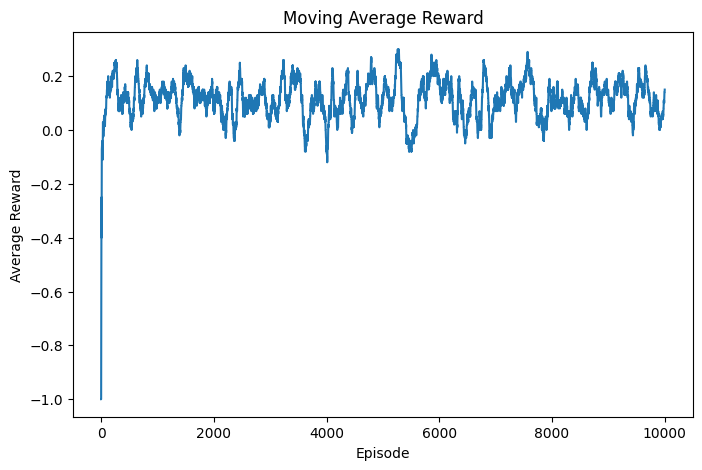

In [28]:
# visualize moving average

plt.figure(figsize=(8,5))

plt.plot(moving_average)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Moving Average Reward")

plt.show()

In [29]:
# combine Q-tables

def combine_q_tables(Q1, Q2, Q3):

    combined = {}

    all_keys = set(Q1.keys()) | set(Q2.keys()) | set(Q3.keys())

    for key in all_keys:

        value1 = Q1.get(key, 0)
        value2 = Q2.get(key, 0)
        value3 = Q3.get(key, 0)

        combined[key] = (value1 + value2 + value3) / 3

    return combined

In [30]:
# Variational Auto-Encoder

# create dataset states
dataset_states = []

# create a game states collector
def collect_game_states():

    board = create_board()

    states = []

    while True:

        # Save current board
        states.append(board.copy())


        # Player X move
        available_actions = get_available_actions(board)

        action = random.choice(available_actions)

        make_move(board, action, PLAYER_X)


        # Check X win
        if check_winner(board, PLAYER_X):
            states.append(board.copy())
            return states


        # Check draw
        if check_draw(board):
            states.append(board.copy())
            return states



        # Player O move
        available_actions = get_available_actions(board)

        action = random.choice(available_actions)

        make_move(board, action, PLAYER_O)


        # Check O win
        if check_winner(board, PLAYER_O):
            states.append(board.copy())
            return states


        # Check draw
        if check_draw(board):
            states.append(board.copy())
            return states

for episode in range(5000):

    game_states = collect_game_states()
    dataset_states.extend(game_states)

In [31]:
# convert boards into vectors
encoded_states = []

for board in dataset_states:
    encoded_states.append(board.flatten())

In [32]:
# convert to numpy array
X = np.array(encoded_states)

# print array shape
print(X.shape)

(66368, 25)


In [33]:
# train-test split

X_train, X_temp = train_test_split(
    X,
    test_size=0.3,
    random_state=42
)

X_val, X_test = train_test_split(
    X_temp,
    test_size=0.5,
    random_state=42
)

# get sizes
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (46457, 25)
Validation: (9955, 25)
Testing: (9956, 25)


In [34]:
# create variational auto-encoder

X_train = X_train.astype("float32")
X_val = X_val.astype("float32")
X_test = X_test.astype("float32")

input_dim = 25
latent_dim = 16

In [35]:
# build encoder

encoder_input = layers.Input(shape=(input_dim,))
x = layers.Dense(64, activation="relu")(encoder_input)
mu = layers.Dense(latent_dim)(x)
log_var = layers.Dense(latent_dim)(x)


# reparametrization

def sampling(args):
    mu, log_var = args

    epsilon = tf.random.normal(
        shape=tf.shape(mu)
    )

    sigma = tf.exp(0.5 * log_var)

    return mu + sigma * epsilon


z = layers.Lambda(sampling)([mu, log_var])

# apply reparametrization
encoder = Model(
    encoder_input,
    [mu, log_var, z]
)

In [36]:
# build decoder
decoder_input = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation="relu")(decoder_input)
x = layers.Dense(64, activation="relu")(x)

decoder_output = layers.Dense(
    input_dim,
    activation="tanh"
)(x)

decoder = Model(
    decoder_input,
    decoder_output
)

In [37]:
# recreate the VAE

# define VAE class
class VAE(Model):

    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()

        self.encoder = encoder
        self.decoder = decoder


    def call(self, inputs):

        mu, log_var, z = self.encoder(inputs)

        reconstruction = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.square(inputs - reconstruction)
        )

        kl_loss = -0.5 * tf.reduce_mean(
            1 + log_var
            - tf.square(mu)
            - tf.exp(log_var)
        )

        self.add_loss(
            reconstruction_loss + 0.001 * kl_loss
        )

        return reconstruction


vae = VAE(
    encoder,
    decoder
)

In [38]:
# compile variational auto-encoder

vae.compile(
    optimizer=tf.keras.optimizers.Adam()
)

In [65]:
# train

history = vae.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=128
)

Epoch 1/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0068 - val_loss: 0.0068
Epoch 2/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0068 - val_loss: 0.0071
Epoch 3/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0068 - val_loss: 0.0068
Epoch 4/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0068 - val_loss: 0.0067
Epoch 5/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0067 - val_loss: 0.0068
Epoch 6/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0067 - val_loss: 0.0068
Epoch 7/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0068 - val_loss: 0.0066
Epoch 8/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0068 - val_loss: 0.0069
Epoch 9/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0068 - val_loss: 0.0066
Epoch 10/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0067 - val_loss: 0.0067
Epoch 11/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0067 - val_loss: 0.0065
Epoch 12/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

In [66]:
# reconstruct test boards

X_reconstructed = vae.predict(X_test)
print(X_reconstructed.shape)

# convert reconstructed values back to Tic-Tac-Toe symbols
X_reconstructed_discrete = np.where(
    X_reconstructed > 0.5,
    1,
    np.where(
        X_reconstructed < -0.5,
        -1,
        0
    )
)

312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step
(9956, 25)


In [67]:
# calculate accuracy per cell
accuracy = np.mean(
    X_reconstructed_discrete == X_test
)

print(
    f"Reconstruction accuracy: {accuracy*100:.2f}%"
)

Reconstruction accuracy: 99.99%


In [68]:
# latent space visualization

mu_values, log_var_values, z_values = encoder.predict(X_test)
print(mu_values.shape)

# calculate occupied cells
occupied_cells = np.sum(
    X_test != 0,
    axis=1
)

# print occupied cells
print(occupied_cells[:10])

312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step
(9956, 16)
[16 12  4 22  2 16  6 22  0 14]


In [69]:
# apply PCA
pca = PCA(
    n_components=2
)

# transform and check latent space
latent_2d = pca.fit_transform(mu_values)
print(latent_2d.shape)

(9956, 2)


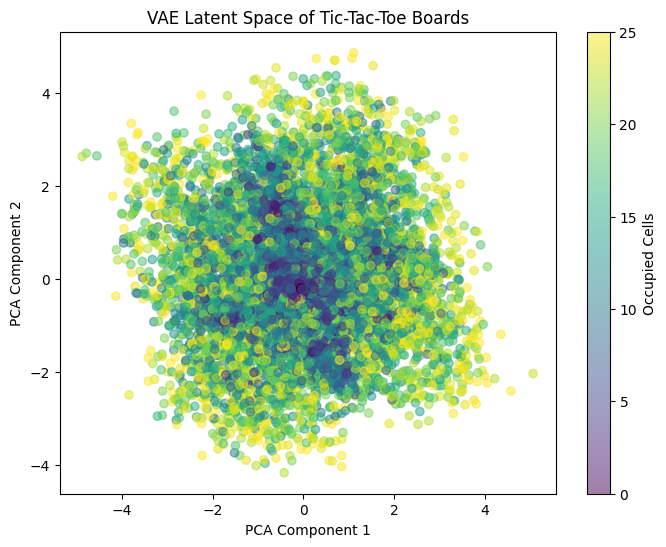

In [70]:
# plot latent space
plt.figure(figsize=(8,6))

plt.scatter(
    latent_2d[:,0],
    latent_2d[:,1],
    c=occupied_cells,
    alpha=0.5
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("VAE Latent Space of Tic-Tac-Toe Boards")

plt.colorbar(
    label="Occupied Cells"
)

plt.show()

In [71]:
board_a_index = 0
board_b_index = 100

z_a = mu_values[board_a_index]
z_b = mu_values[board_b_index]

In [72]:
# create interpolation points
interpolation_steps = np.linspace(0, 1, 5)
interpolated_z = []

for t in interpolation_steps:
    z_t = (1-t)*z_a + t*z_b
    interpolated_z.append(z_t)

interpolated_z = np.array(interpolated_z)

# check interpolation shapes
print(interpolated_z.shape)

# decode latent vectors
decoded_boards = decoder.predict(interpolated_z)

# check decoded vectors
print(decoded_boards.shape)

(5, 16)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
(5, 25)


In [73]:
# convert outputs back to board symbols
decoded_boards_discrete = np.where(
    decoded_boards > 0.5,
    1,
    np.where(
        decoded_boards < -0.5,
        -1,
        0
    )
)

# display interpolation sequence
for i, board in enumerate(decoded_boards_discrete):

    print(f"Step {i}")
    print(board.reshape(5,5))
    print()

Step 0
[[ 0  0  1  1  1]
 [ 0  1 -1  0 -1]
 [-1  1  0 -1  0]
 [ 1  1 -1  1 -1]
 [-1  0  0  0 -1]]

Step 1
[[-1  1  0  1  1]
 [-1  1 -1  0 -1]
 [ 1  1  0 -1  0]
 [ 1  1 -1  1  0]
 [-1 -1 -1  0 -1]]

Step 2
[[-1  1 -1  1  1]
 [ 0  1 -1  0 -1]
 [ 1  1  0 -1  0]
 [ 1  1 -1  1  1]
 [ 0 -1 -1 -1 -1]]

Step 3
[[-1  1  0  0  1]
 [ 1  1 -1  0 -1]
 [ 1  0  0  0  0]
 [ 0  0  0  0  1]
 [ 1 -1 -1 -1 -1]]

Step 4
[[-1  0  1  0  1]
 [ 0  0 -1  0 -1]
 [ 0  0  0  1  0]
 [ 0  0  0  0  0]
 [ 0  0  0  0  0]]



In [74]:
# generate random latent vectors
num_samples = 10

z_samples = np.random.normal(
    size=(num_samples, latent_dim)
)

print(z_samples.shape)

# decode latent vectors
sampled_boards = decoder.predict(z_samples)

print(sampled_boards.shape)

(10, 16)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
(10, 25)


In [75]:
# convert decoder output to Tic-Tac-Toe symbols
sampled_boards_discrete = np.where(
    sampled_boards > 0.5,
    1,
    np.where(
        sampled_boards < -0.5,
        -1,
        0
    )
)

# display generated boards
for i, board in enumerate(sampled_boards_discrete):

    print(f"Sample {i}")
    print(board.reshape(5,5))
    print()

Sample 0
[[-1  0 -1 -1  1]
 [ 1  1  1 -1  1]
 [-1 -1  0 -1  1]
 [ 1  1  1 -1  1]
 [ 1  1  1  1  1]]

Sample 1
[[ 1  1 -1 -1  1]
 [ 1  0 -1  0  1]
 [ 1 -1  1 -1  0]
 [ 1  0 -1  0  1]
 [-1  1  0 -1  0]]

Sample 2
[[-1  1 -1 -1  1]
 [-1  0  0 -1  1]
 [-1  0  1  1  1]
 [ 0  1 -1  1  1]
 [-1  0 -1  1 -1]]

Sample 3
[[ 1  0 -1 -1  1]
 [ 0  0  1  0 -1]
 [-1  1  0  1  0]
 [-1  0  1  1  1]
 [ 1 -1  1 -1  0]]

Sample 4
[[ 1 -1  0 -1 -1]
 [-1  0  0 -1 -1]
 [-1  1  0  0  1]
 [ 0  1  0  0 -1]
 [ 0 -1  1  1  1]]

Sample 5
[[ 0 -1  1 -1 -1]
 [ 1 -1  0  1 -1]
 [ 1  1  1 -1  0]
 [ 0  0  0 -1  0]
 [ 1  1  1  1  1]]

Sample 6
[[ 1  1  0 -1 -1]
 [-1  0  1  0  1]
 [-1 -1  1  0  0]
 [ 1 -1  1  1 -1]
 [ 1  1  1 -1  1]]

Sample 7
[[-1 -1  1 -1  1]
 [ 1  1  0  0  1]
 [ 0  0 -1  1  0]
 [-1 -1  0  0 -1]
 [ 0 -1  1  1  1]]

Sample 8
[[ 1 -1 -1 -1  1]
 [ 1 -1  1  0  1]
 [ 0 -1  0 -1  0]
 [ 0  0 -1  1  1]
 [-1  1  0  0  1]]

Sample 9
[[-1  1 -1  0  1]
 [ 0 -1  0  0  1]
 [-1  0 -1 -1  1]
 [ 0  0  1  1 -1]
 [-1  1  1

In [76]:
# sample new latent points
num_generated_samples = 1000

z_generated = np.random.normal(
    size=(num_generated_samples, latent_dim)
)

print(z_generated.shape)

# decode to board states
generated_boards = decoder.predict(z_generated)
print(generated_boards.shape)

# convert to board states
generated_boards_discrete = np.where(
    generated_boards > 0.5,
    1,
    np.where(
        generated_boards < -0.5,
        -1,
        0
    )
)

(1000, 16)
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
(1000, 25)


In [77]:
# extract visited states
visited_states = set(Q.keys())

# print visited states
print("Visited states:", len(visited_states))

# verify visited states and Q-table keys
print(next(iter(visited_states)))
print(next(iter(Q.keys())))

Visited states: 113224
((1, -1, -1, 0, 1, -1, 1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, 1, -1, 1, -1, 1, 1, -1, -1), (0, 3))
((0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0), (0, 0))


In [78]:
# convert generated states into comparable states

generated_states = []

for board in generated_boards_discrete:

    state = tuple(board)
    generated_states.append(state)

In [79]:
# find unseen states
unseen_states = []

for state in generated_states:
    if state not in visited_states:
        unseen_states.append(state)


print("Generated states:", len(generated_states))
print("Unseen states:", len(unseen_states))

Generated states: 1000
Unseen states: 1000


In [80]:
# check if board is valid

def is_valid_board(board):

    x_count = np.sum(board == PLAYER_X)
    o_count = np.sum(board == PLAYER_O)

    if abs(x_count - o_count) > 1:
        return False

    return True

In [81]:
# filter generated boards

valid_boards = []

for board in generated_boards_discrete:

    board = board.reshape(n, n)

    if is_valid_board(board):
        valid_boards.append(board)

print("Generated boards:", len(generated_boards_discrete))
print("Valid boards:", len(valid_boards))

# compute acceptance rate
acceptance_rate = len(valid_boards) / len(generated_boards_discrete)
print(f"Acceptance rate: {acceptance_rate*100:.2f}%")

Generated boards: 1000
Valid boards: 361
Acceptance rate: 36.10%


In [82]:
# filter unseen boards

unseen_boards = []

for board in valid_boards:

    state = tuple(board.flatten())

    if state not in visited_states:
        unseen_boards.append(board)

print("Unseen boards:", len(unseen_boards))

Unseen boards: 361


In [83]:
# compare both agents

def baseline_action(board):

    state = tuple(board.flatten())

    available_actions = get_available_actions(board)

    if not available_actions:
        return None

    q_values = {}

    for action in available_actions:

        if (state, action) in Q:
            q_values[action] = Q[(state, action)]
        else:
            q_values[action] = 0

    best_action = max(
        q_values,
        key=q_values.get
    )

    return best_action

In [85]:
# compare both agents using VAE

# collect unique visited states
visited_boards = np.array(
    list(set(state for state, action in visited_states)),
    dtype=np.float32
)


print("Visited board array:", visited_boards.shape)


# encode all boards together
latent_states = encoder.predict(
    visited_boards,
    verbose=0,
    batch_size=512
)


latent_boards = visited_boards

print("Visited boards:", len(latent_boards))
print("Latent matrix:", latent_boards.shape)
print("Stored latent boards:", len(latent_boards))
print("Unseen boards:", len(unseen_boards))

Visited board array: (107189, 25)
Visited boards: 107189
Latent matrix: (107189, 25)
Stored latent boards: 107189
Unseen boards: 361


In [86]:
# compare VAE agent with baseline agent

def vae_action(board):

    # encode current board
    z_board = encoder.predict(
        board.reshape(1, -1),
        verbose=0
    )[0]


    # calculate distances
    distances = np.linalg.norm(
        latent_states - z_board,
        axis=1
    )


    # find 10 nearest latent states
    nearest_indices = np.argpartition(
        distances,
        10
    )[:10]


    estimated_q = {}

    sigma = max(
        np.median(distances[nearest_indices]),
        1e-8
    )


    for action in get_available_actions(board):

        numerator = 0
        denominator = 0

        for i in nearest_indices:

            state = tuple(latent_boards[i])

            if (state, action) in Q:

                distance = distances[i]

                weight = np.exp(
                    -(distance**2) / (sigma**2)
                )

                numerator += weight * Q[(state, action)]
                denominator += weight


        if denominator > 0:
            estimated_q[action] = numerator / denominator


    if estimated_q:

        return max(
            estimated_q,
            key=estimated_q.get
        )


    return random.choice(
        get_available_actions(board)
    )

In [ ]:
# check if an action is safe

def is_safe_action(board, action, agent_player, opponent_player):

    # copy board so the original is not modified
    test_board = board.copy()

    # simulate agent's move
    make_move(
        test_board,
        action,
        agent_player
    )

    # check opponent's possible moves
    opponent_actions = get_available_actions(test_board)

    for opp_action in opponent_actions:

        temp_board = test_board.copy()

        make_move(
            temp_board,
            opp_action,
            opponent_player
        )

        # opponent can win immediately
        if check_winner(
            temp_board,
            opponent_player
        ):
            return False

    return True

In [ ]:
# evaluate safe actions for both agents

def evaluate_safe_actions(unseen_boards):

    baseline_safe = 0
    vae_safe = 0
    evaluated_boards = 0

    for board in unseen_boards:

        # get actions from both agents
        baseline_move = baseline_action(board)
        vae_move = vae_action(board)

        # skip if an agent cannot move
        if baseline_move is None or vae_move is None:
            continue


        # check baseline safety
        if is_safe_action(
            board,
            baseline_move,
            PLAYER_O,
            PLAYER_X
        ):
            baseline_safe += 1


        # check VAE safety
        if is_safe_action(
            board,
            vae_move,
            PLAYER_X,
            PLAYER_O
        ):
            vae_safe += 1


        evaluated_boards += 1


    baseline_rate = baseline_safe / evaluated_boards * 100
    vae_rate = vae_safe / evaluated_boards * 100

    return baseline_rate, vae_rate